# Các Mô hình Học Máy Nâng Cao: XGBoost, Random Forest & LightGBM
## Mục tiêu:

- Xây dựng và so sánh **3 mô hình**: XGBoost, Random Forest, LightGBM.
- Thực hiện **2 kịch bản** cho mỗi mô hình:
  - Có dùng `duration` (Benchmark – ceiling performance).
  - Không dùng `duration` (Thực tế – mô phỏng dự đoán trước khi nhấc máy).
- Tối ưu siêu tham số bằng **RandomizedSearchCV**.
- Đánh giá: ROC-AUC, PR-AUC, F1, Confusion Matrix, ROC Curve, PR Curve.
- Giải thích mô hình bằng **Feature Importance** và **SHAP Values**.
- So sánh kết quả với Logistic Regression và giữa các mô hình với nhau.

## Cài đặt thư viện

In [ ]:
# !pip install xgboost lightgbm shap imbalanced-learn --quiet

## Import thư viện

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ML + preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score,
)

# SMOTE
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# LightGBM
import lightgbm as lgb

# SHAP
import shap

# Scipy
from scipy.stats import randint, uniform

# Style
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

## Đọc dữ liệu






In [2]:
DATA_PATH = 'processed_bank_data.csv'

df = pd.read_csv(DATA_PATH)

print(f"Shape dữ liệu: {df.shape}")
print(f"\nPhân phối nhãn target 'y':")
print(df['y'].value_counts())
print(f"\nTỷ lệ lớp dương (y=1): {df['y'].mean():.2%}")
df.head()

Shape dữ liệu: (41188, 57)

Phân phối nhãn target 'y':
y
0    36548
1     4640
Name: count, dtype: int64

Tỷ lệ lớp dương (y=1): 11.27%


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,age_group_adult,age_group_middle,age_group_senior
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191,...,False,True,False,False,False,True,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191,...,False,True,False,False,False,True,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191,...,False,True,False,False,False,True,False,True,False,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191,...,False,True,False,False,False,True,False,True,False,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191,...,False,True,False,False,False,True,False,False,True,False


## Chuẩn bị dữ liệu


In [3]:
# Thêm đặc trưng mới: khách hàng đã được liên hệ trước đó chưa?
# pdays = 999 nghĩa là chưa từng liên hệ
df['is_contacted_before'] = (df['pdays'] != 999).astype(int)

# Tách features và target
X = df.drop(columns=['y'])
y = df['y']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, shuffle=False)


print(f"Train size: {X_train.shape[0]:,} mẫu")
print(f"Test  size: {X_test.shape[0]:,} mẫu")
print(f"\nPhân phối y_train: {y_train.value_counts().to_dict()}")
print(f"Phân phối y_test : {y_test.value_counts().to_dict()}")

Train size: 32,950 mẫu
Test  size: 8,238 mẫu

Phân phối y_train: {0: 30850, 1: 2100}
Phân phối y_test : {0: 5698, 1: 2540}


In [ ]:
# Tạo 2 kịch bản
X_train_with_dur = X_train.copy()
X_test_with_dur  = X_test.copy()

X_train_no_dur = X_train.drop(columns=['duration'])
X_test_no_dur  = X_test.drop(columns=['duration'])

print("Kịch bản 1 – Có duration: ", X_train_with_dur.shape[1], "features")
print("Kịch bản 2 – Không duration:", X_train_no_dur.shape[1], "features")

Kịch bản 1 – Có duration:  57 features
Kịch bản 2 – Không duration: 56 features


In [ ]:
# Tiền xử lý dữ liệu và áp dụng SMOTE trên tập train
def process_scenario(X_tr, X_te, y_tr, apply_smote=True):

    # Ép kiểu về float
    X_tr = X_tr.astype(float)
    X_te = X_te.astype(float)

    # StandardScaler (fit trên train, transform cả 2)
    scaler = StandardScaler()
    X_tr_scaled = pd.DataFrame(
        scaler.fit_transform(X_tr), columns=X_tr.columns
    )
    X_te_scaled = pd.DataFrame(
        scaler.transform(X_te), columns=X_te.columns
    )

    if apply_smote:
        # SMOTE chỉ áp dụng trên tập Train
        smote = SMOTE(random_state=RANDOM_STATE)
        X_tr_res, y_tr_res = smote.fit_resample(X_tr_scaled, y_tr)
        print(f"  Sau SMOTE → Train: {X_tr_res.shape[0]:,} mẫu | "
              f"Lớp 0: {(y_tr_res==0).sum():,} | Lớp 1: {(y_tr_res==1).sum():,}")
    else:
        X_tr_res, y_tr_res = X_tr_scaled, y_tr

    return X_tr_res, y_tr_res, X_te_scaled, scaler


print("Kịch bản 1 – Có duration:")
X_tr1, y_tr1, X_te1, scaler1 = process_scenario(X_train_with_dur, X_test_with_dur, y_train)

print("Kịch bản 2 – Không duration:")
X_tr2, y_tr2, X_te2, scaler2 = process_scenario(X_train_no_dur, X_test_no_dur, y_train)

Kịch bản 1 – Có duration:
  Sau SMOTE → Train: 61,700 mẫu | Lớp 0: 30,850 | Lớp 1: 30,850
Kịch bản 2 – Không duration:
  Sau SMOTE → Train: 61,700 mẫu | Lớp 0: 30,850 | Lớp 1: 30,850


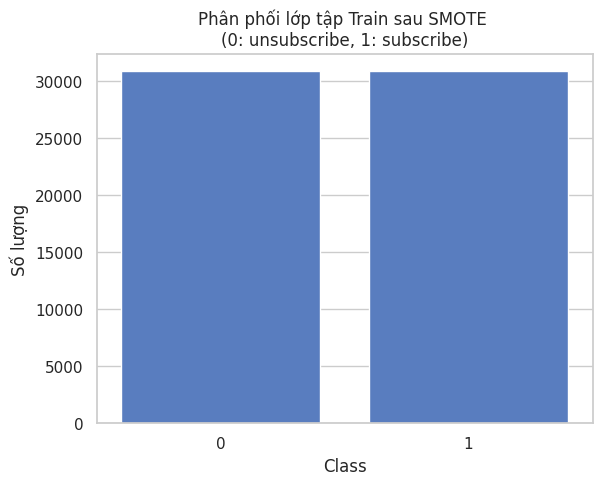

In [ ]:
sns.countplot(x=y_tr1)
plt.title('Phân phối lớp tập Train sau SMOTE \n(0: unsubscribe, 1: subscribe)')
plt.xlabel('Class')
plt.ylabel('Số lượng')
plt.show()

## Tối ưu Siêu tham số bằng RandomizedSearchCV  
> Tối ưu theo chỉ số **ROC-AUC**.

In [ ]:
# Không gian tham số cần tìm kiếm
param_dist = {
    'n_estimators'      : randint(100, 600),
    'max_depth'         : randint(3, 10),
    'learning_rate'     : uniform(0.01, 0.3),
    'subsample'         : uniform(0.6, 0.4),       # [0.6, 1.0]
    'colsample_bytree'  : uniform(0.6, 0.4),       # [0.6, 1.0]
    'min_child_weight'  : randint(1, 10),
    'gamma'             : uniform(0, 0.5),
    'reg_alpha'         : uniform(0, 1),            # L1
    'reg_lambda'        : uniform(0.5, 2),          # L2
    'scale_pos_weight'  : uniform(1, 5),            # xử lý mất cân bằng
}

cv = TimeSeriesSplit(n_splits=5)

def tune_xgboost(X_tr, y_tr, n_iter=50, label=''):
    print(f"Siêu tham số tốt nhất cho {label}:")
    base_model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        tree_method='hist',
        n_jobs=-1,
    )
    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        verbose=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    search.fit(X_tr, y_tr)
    print(f"   Best ROC-AUC (CV): {search.best_score_:.4f}")
    print(f"   Best params: {search.best_params_}")
    return search.best_estimator_, search

# Kịch bản 1
best_xgb1, search1 = tune_xgboost(X_tr1, y_tr1, n_iter=50, label='Kịch bản 1 - Có duration')

# Kịch bản 2
best_xgb2, search2 = tune_xgboost(X_tr2, y_tr2, n_iter=50, label='Kịch bản 2 - Không duration')

Siêu tham số tốt nhất cho Kịch bản 1 - Có duration:
Fitting 5 folds for each of 50 candidates, totalling 250 fits
   Best ROC-AUC (CV): nan
   Best params: {'colsample_bytree': np.float64(0.749816047538945), 'gamma': np.float64(0.4753571532049581), 'learning_rate': np.float64(0.22959818254342154), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 202, 'reg_alpha': np.float64(0.44583275285359114), 'reg_lambda': np.float64(0.6999498316360058), 'scale_pos_weight': np.float64(3.2962444598293357), 'subsample': np.float64(0.7334834444556088)}
Siêu tham số tốt nhất cho Kịch bản 2 - Không duration:
Fitting 5 folds for each of 50 candidates, totalling 250 fits
   Best ROC-AUC (CV): nan
   Best params: {'colsample_bytree': np.float64(0.749816047538945), 'gamma': np.float64(0.4753571532049581), 'learning_rate': np.float64(0.22959818254342154), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 202, 'reg_alpha': np.float64(0.44583275285359114), 'reg_lambda': np.float64(0.6999498316360058)

## Đánh giá mô hình



BÁO CÁO MÔ HÌNH: KỊCH BẢN 1 – CÓ DURATION (BENCHMARK)

 1. CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Từ chối (0)       0.72      0.96      0.83      5698
  Đồng ý (1)       0.68      0.17      0.27      2540

    accuracy                           0.72      8238
   macro avg       0.70      0.57      0.55      8238
weighted avg       0.71      0.72      0.65      8238

 2. CHỈ SỐ TỔNG HỢP:
   ROC-AUC          : 0.7981
   PR-AUC           : 0.5828
   F1-Score (class 1): 0.2668
   Balanced Accuracy: 0.5654


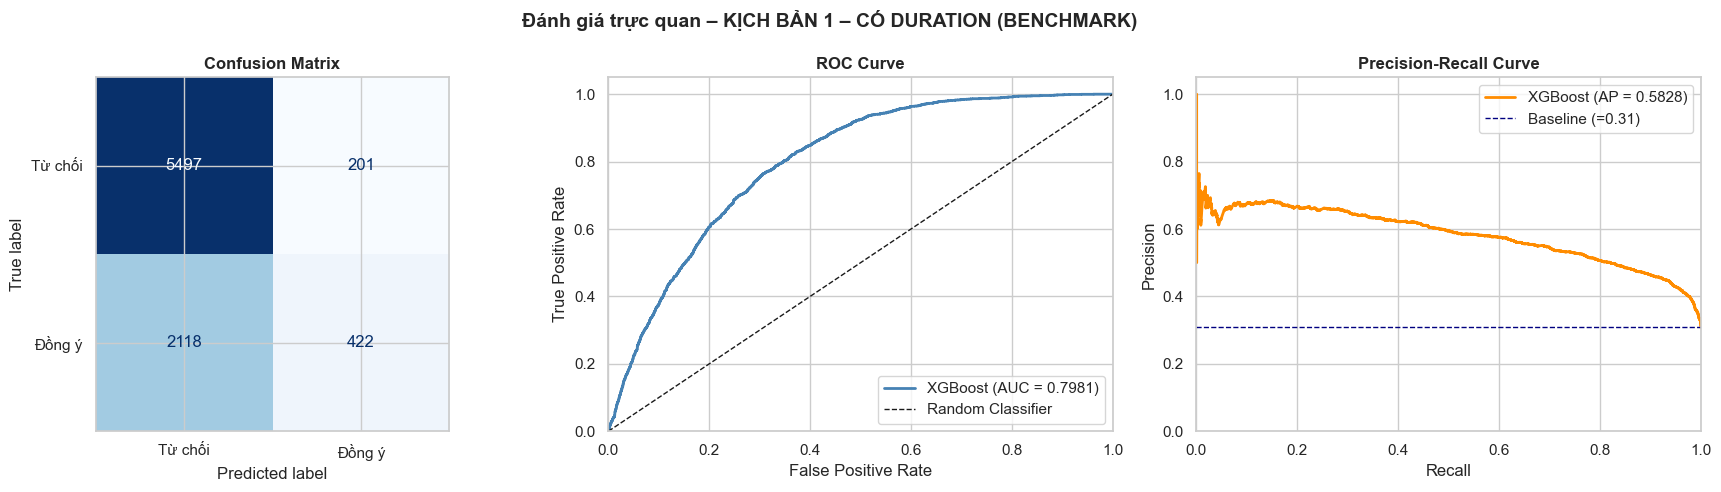



BÁO CÁO MÔ HÌNH: KỊCH BẢN 2 – KHÔNG DURATION (THỰC TẾ)

 1. CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Từ chối (0)       0.73      0.88      0.80      5698
  Đồng ý (1)       0.49      0.26      0.34      2540

    accuracy                           0.69      8238
   macro avg       0.61      0.57      0.57      8238
weighted avg       0.65      0.69      0.65      8238

 2. CHỈ SỐ TỔNG HỢP:
   ROC-AUC          : 0.6489
   PR-AUC           : 0.4313
   F1-Score (class 1): 0.3351
   Balanced Accuracy: 0.5675


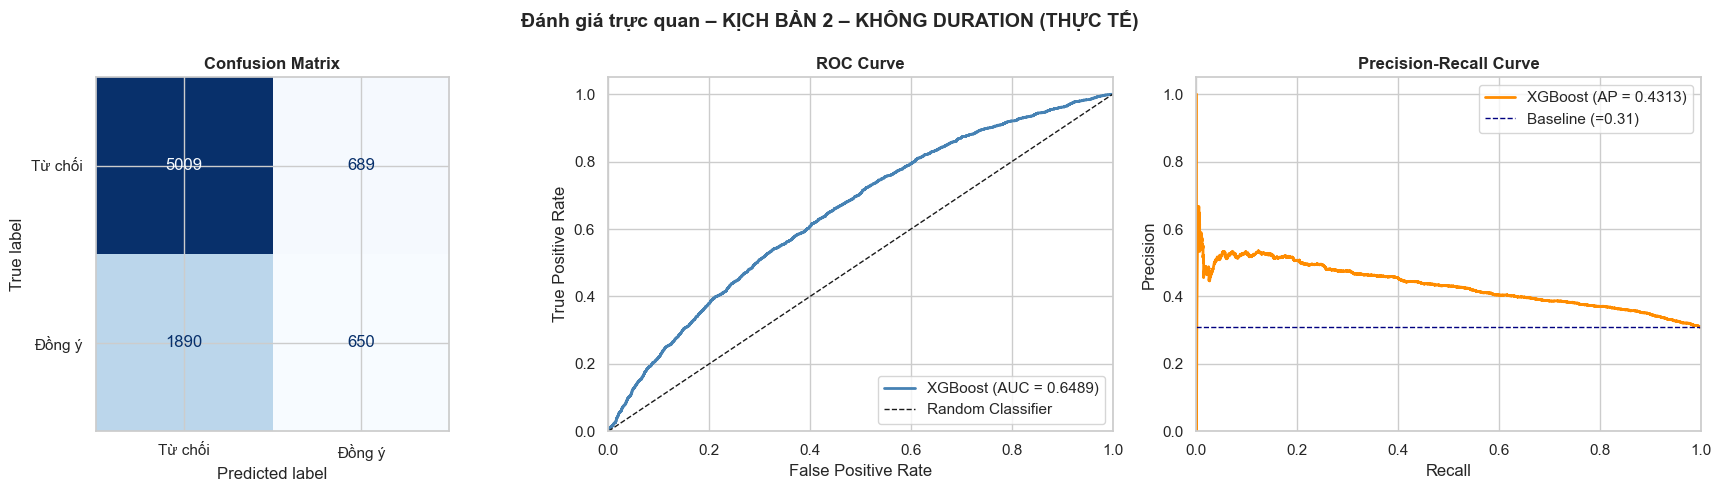

In [ ]:
"""
Đánh giá mô hình XGBoost:
- Classification Report
- ROC-AUC, PR-AUC, F1, Balanced Accuracy
- Confusion Matrix
- ROC Curve & PR Curve
"""
def evaluate_model(model, X_te, y_te, scenario_name):

    print(f"{'='*60}")
    print(f"BÁO CÁO MÔ HÌNH: {scenario_name}")
    print(f"{'='*60}")

    y_pred       = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1]

    # Các chỉ số tổng hợp
    roc_auc  = roc_auc_score(y_te, y_pred_proba)
    pr_auc   = average_precision_score(y_te, y_pred_proba)
    f1       = f1_score(y_te, y_pred, pos_label=1)
    bal_acc  = balanced_accuracy_score(y_te, y_pred)

    print("\n 1. CLASSIFICATION REPORT:")
    print(classification_report(y_te, y_pred,
                                target_names=['Từ chối (0)', 'Đồng ý (1)']))

    print(" 2. CHỈ SỐ TỔNG HỢP:")
    print(f"   ROC-AUC          : {roc_auc:.4f}")
    print(f"   PR-AUC           : {pr_auc:.4f}")
    print(f"   F1-Score (class 1): {f1:.4f}")
    print(f"   Balanced Accuracy: {bal_acc:.4f}")

    # Confusion Matrix
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Đánh giá trực quan – {scenario_name}", fontsize=14, fontweight='bold')

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Từ chối', 'Đồng ý'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title('Confusion Matrix', fontweight='bold')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_pred_proba)
    axes[1].plot(fpr, tpr, color='steelblue', lw=2,
                 label=f'XGBoost (AUC = {roc_auc:.4f})')
    axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve', fontweight='bold')
    axes[1].legend(loc='lower right')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])

    # Precision-Recall Curve
    prec, rec, _ = precision_recall_curve(y_te, y_pred_proba)
    baseline = y_te.mean()
    axes[2].plot(rec, prec, color='darkorange', lw=2,
                 label=f'XGBoost (AP = {pr_auc:.4f})')
    axes[2].axhline(y=baseline, color='navy', linestyle='--', lw=1,
                    label=f'Baseline (={baseline:.2f})')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall Curve', fontweight='bold')
    axes[2].legend(loc='upper right')
    axes[2].set_xlim([0.0, 1.0])
    axes[2].set_ylim([0.0, 1.05])

    plt.tight_layout()
    plt.show()

    return {
        'roc_auc': roc_auc,
        'pr_auc' : pr_auc,
        'f1'     : f1,
        'bal_acc': bal_acc,
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred,
    }


print("\n")
results1 = evaluate_model(best_xgb1, X_te1, y_test,
                          "KỊCH BẢN 1 – CÓ DURATION (BENCHMARK)")
print("\n")
results2 = evaluate_model(best_xgb2, X_te2, y_test,
                          "KỊCH BẢN 2 – KHÔNG DURATION (THỰC TẾ)")

## Giải thích mô hình

### 1. Feature Importance (Gain)

=== Kịch bản 1 - Có duration ===


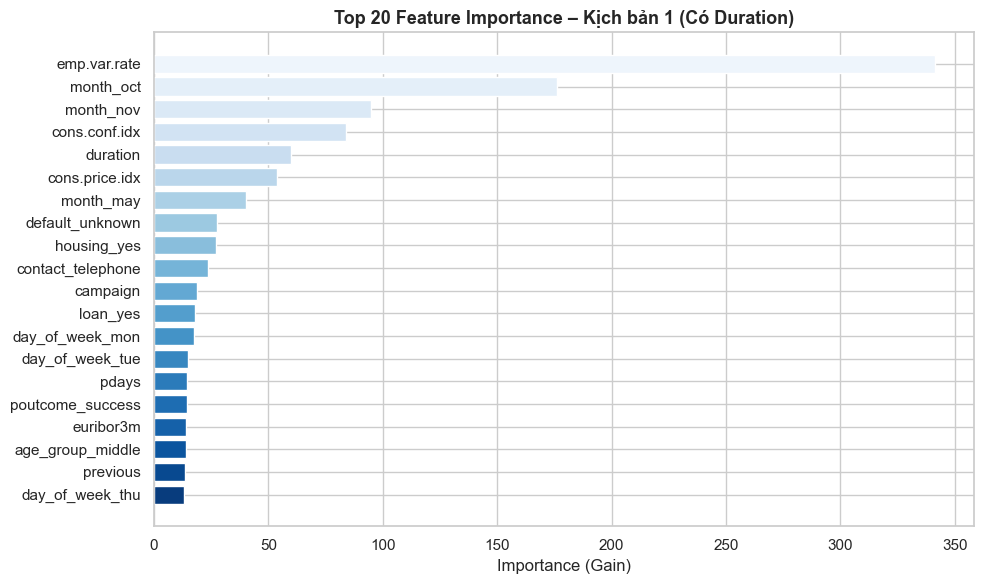


 Top 20 features (Gain):
   emp.var.rate                       : 341.34
   month_oct                          : 176.11
   month_nov                          : 94.70
   cons.conf.idx                      : 84.02
   duration                           : 59.69
   cons.price.idx                     : 53.91
   month_may                          : 40.40
   default_unknown                    : 27.44
   housing_yes                        : 27.20
   contact_telephone                  : 23.57
   campaign                           : 18.91
   loan_yes                           : 18.07
   day_of_week_mon                    : 17.37
   day_of_week_tue                    : 14.94
   pdays                              : 14.39
   poutcome_success                   : 14.26
   euribor3m                          : 14.04
   age_group_middle                   : 14.00
   previous                           : 13.46
   day_of_week_thu                    : 13.18

=== Kịch bản 2 - Không duration ===


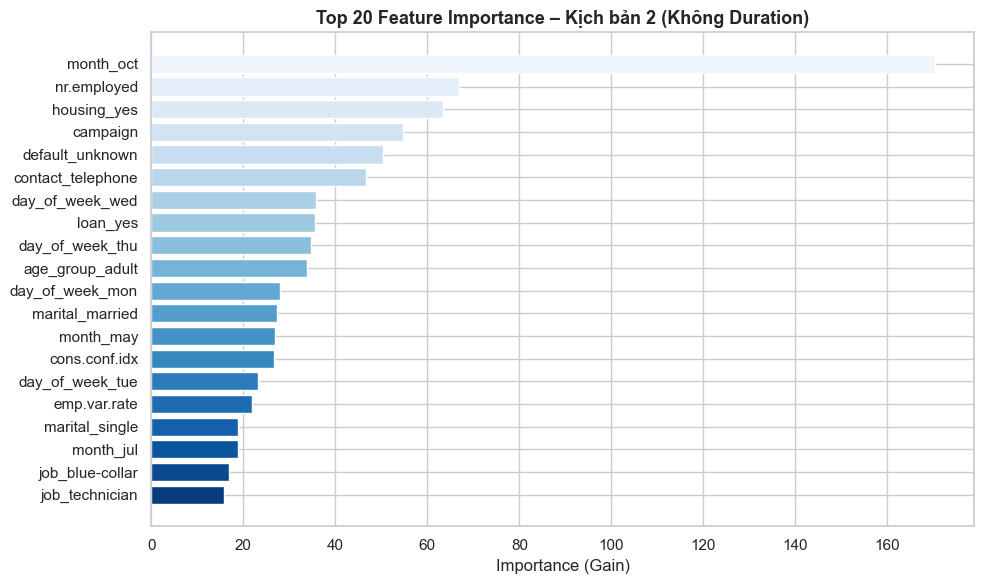


 Top 20 features (Gain):
   month_oct                          : 170.29
   nr.employed                        : 66.89
   housing_yes                        : 63.36
   campaign                           : 54.75
   default_unknown                    : 50.45
   contact_telephone                  : 46.68
   day_of_week_wed                    : 35.75
   loan_yes                           : 35.60
   day_of_week_thu                    : 34.70
   age_group_adult                    : 33.80
   day_of_week_mon                    : 28.01
   marital_married                    : 27.25
   month_may                          : 26.97
   cons.conf.idx                      : 26.66
   day_of_week_tue                    : 23.17
   emp.var.rate                       : 21.86
   marital_single                     : 18.91
   month_jul                          : 18.87
   job_blue-collar                    : 16.86
   job_technician                     : 15.90


In [ ]:
"""
Vẽ top N features quan trọng nhất theo chỉ số 'gain' của XGBoost.
'gain' = tổng mức giảm impurity khi dùng feature này để split.
"""
def plot_feature_importance(model, feature_names, top_n=20, title=''):

    importance = model.get_booster().get_score(importance_type='gain')
    fi_df = pd.DataFrame({
        'feature'   : list(importance.keys()),
        'importance': list(importance.values())
    }).sort_values('importance', ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
                    color=sns.color_palette('Blues_r', top_n))
    plt.xlabel('Importance (Gain)', fontsize=12)
    plt.title(f'Top {top_n} Feature Importance – {title}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n Top {top_n} features (Gain):")
    for _, row in fi_df.iterrows():
        print(f"   {row['feature']:<35s}: {row['importance']:.2f}")
    return fi_df


print("=== Kịch bản 1 - Có duration ===")
fi1 = plot_feature_importance(best_xgb1, X_tr1.columns, top_n=20,
                              title='Kịch bản 1 (Có Duration)')

print("\n=== Kịch bản 2 - Không duration ===")
fi2 = plot_feature_importance(best_xgb2, X_tr2.columns, top_n=20,
                              title='Kịch bản 2 (Không Duration)')

### 2. SHAP Values


======= KỊCH BẢN 2 – KHÔNG DURATION (thực tế) =======

SHAP Summary Plot (Beeswarm):


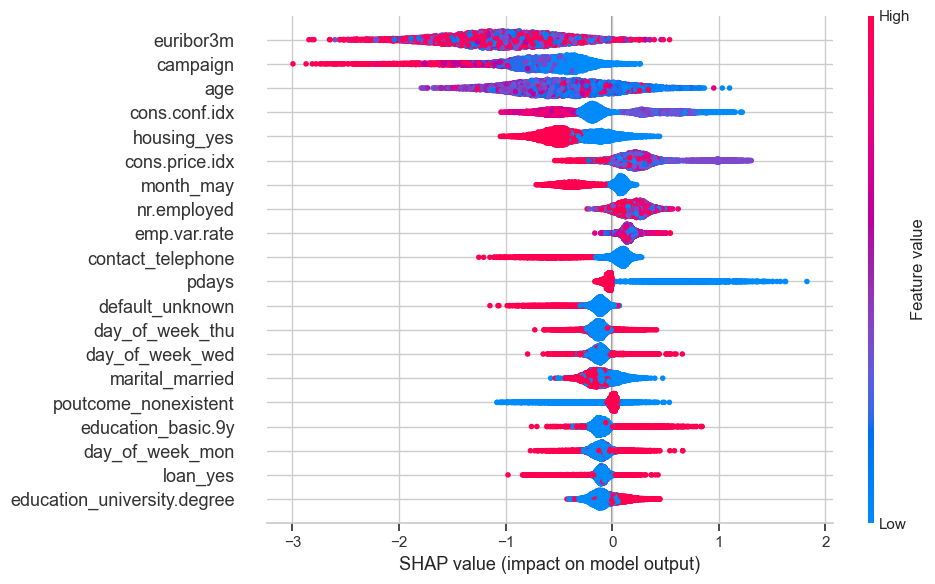


SHAP Bar Plot (Mean |SHAP|):


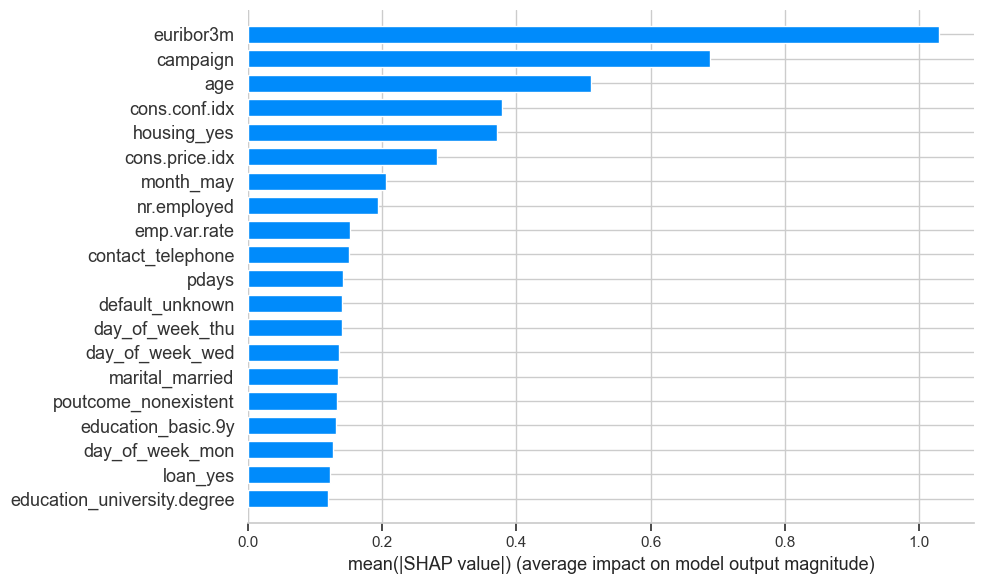

In [ ]:
def shap_analysis(model, X_te, title='', max_display=20):

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_te)

    # Beeswarm plot (tổng quan tác động của từng feature)
    print("\nSHAP Summary Plot (Beeswarm):")
    shap.summary_plot(shap_values, X_te, max_display=max_display,
                      show=True, plot_size=(10, 6))

    # Bar plot (tầm quan trọng trung bình theo SHAP)
    print("\nSHAP Bar Plot (Mean |SHAP|):")
    shap.summary_plot(shap_values, X_te, plot_type='bar',
                      max_display=max_display, show=True, plot_size=(10, 6))

    return explainer, shap_values


print("======= KỊCH BẢN 2 – KHÔNG DURATION (thực tế) =======")
explainer2, shap_vals2 = shap_analysis(best_xgb2, X_te2)

SHAP Waterfall Plot – Giải thích mẫu index 0:


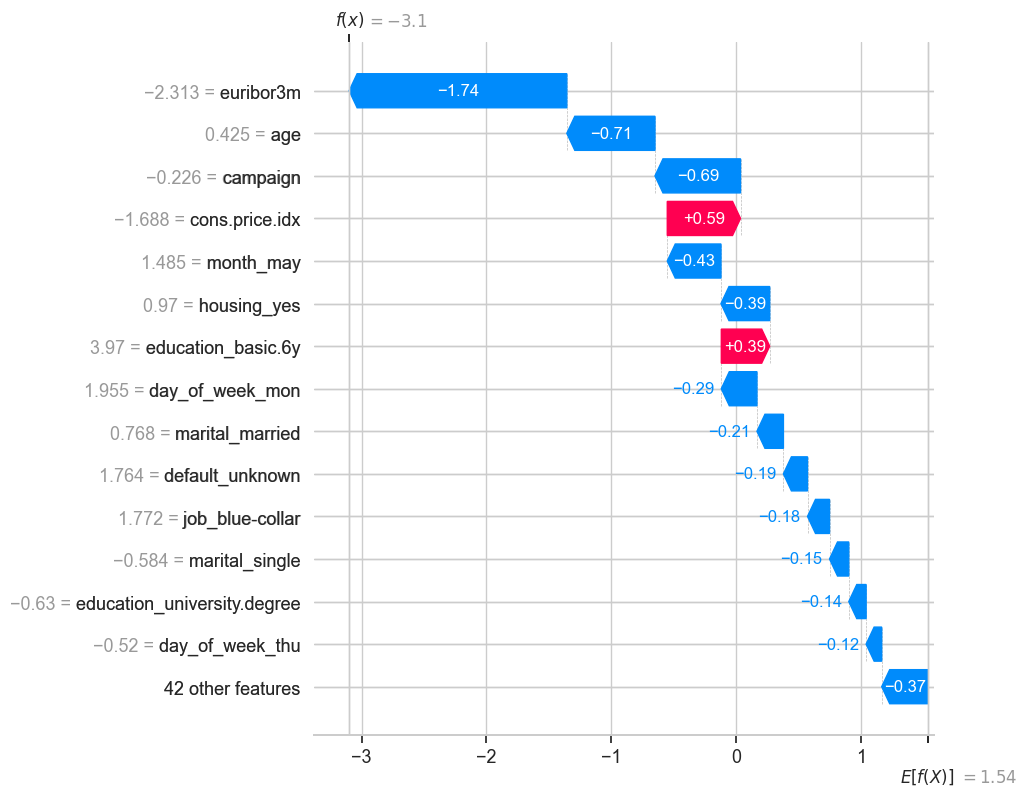

In [ ]:
# SHAP Waterfall cho 1 mẫu cụ thể - cho thấy từng feature đóng góp bao nhiêu vào dự đoán cụ thể đó
print("SHAP Waterfall Plot – Giải thích mẫu index 0:")
shap_explanation = shap.Explanation(
    values=shap_vals2[0],
    base_values=explainer2.expected_value,
    data=X_te2.iloc[0],
    feature_names=X_te2.columns.tolist()
)
shap.waterfall_plot(shap_explanation, max_display=15)

## Phân tích Ngưỡng Quyết định (Decision Threshold)

> Mặc định XGBoost dùng ngưỡng 0.5. Nhưng do bài toán mất cân bằng nên điều chỉnh ngưỡng để cải thiện F1-Score và Recall.

=== Kịch bản 2 – Phân tích ngưỡng ===


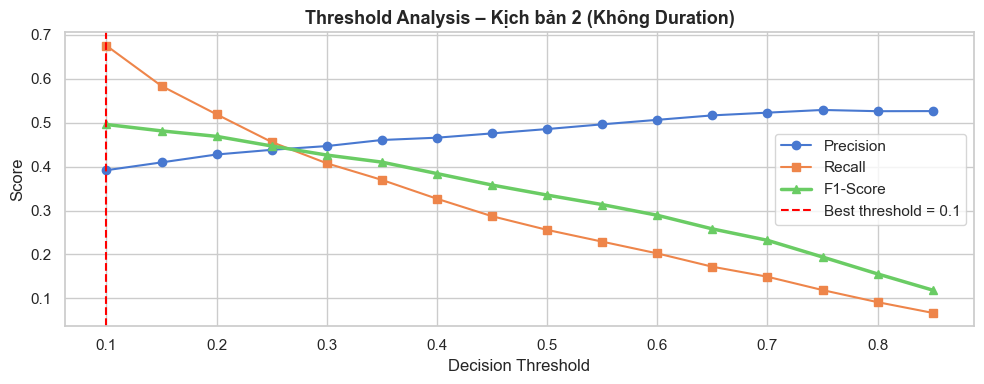

 Ngưỡng tốt nhất (theo F1): 0.1
 Precision=0.3917 | Recall=0.6752 | F1=0.4958


In [ ]:
def threshold_analysis(y_te, y_proba, scenario_name):
    thresholds = np.arange(0.1, 0.9, 0.05)
    records = []

    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        records.append({
            'threshold': round(t, 2),
            'precision': pd.Series(y_pred_t).eq(1).mul(pd.Series(y_te.values).eq(1)).sum() /
                         max(y_pred_t.sum(), 1),
            'recall'   : (y_pred_t[y_te.values == 1] == 1).sum() / (y_te == 1).sum(),
            'f1'       : f1_score(y_te, y_pred_t, pos_label=1, zero_division=0),
        })

    df_thresh = pd.DataFrame(records)
    best_thresh = df_thresh.loc[df_thresh['f1'].idxmax(), 'threshold']

    plt.figure(figsize=(10, 4))
    plt.plot(df_thresh['threshold'], df_thresh['precision'], label='Precision', marker='o')
    plt.plot(df_thresh['threshold'], df_thresh['recall'],    label='Recall',    marker='s')
    plt.plot(df_thresh['threshold'], df_thresh['f1'],        label='F1-Score',  marker='^', lw=2.5)
    plt.axvline(x=best_thresh, color='red', linestyle='--',
                label=f'Best threshold = {best_thresh}')
    plt.xlabel('Decision Threshold', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.title(f'Threshold Analysis – {scenario_name}', fontsize=13, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f" Ngưỡng tốt nhất (theo F1): {best_thresh}")
    best_row = df_thresh[df_thresh['threshold'] == best_thresh].iloc[0]
    print(f" Precision={best_row['precision']:.4f} | "
          f"Recall={best_row['recall']:.4f} | F1={best_row['f1']:.4f}")
    return best_thresh, df_thresh


print("=== Kịch bản 2 – Phân tích ngưỡng ===")
best_t2, df_thresh2 = threshold_analysis(
    y_test, results2['y_pred_proba'], 'Kịch bản 2 (Không Duration)'
)

In [ ]:
# Đánh giá lại Kịch bản 2 với ngưỡng tốt nhất
y_pred_best_t = (results2['y_pred_proba'] >= best_t2).astype(int)

print(f"\n Classification Report với ngưỡng tối ưu (threshold={best_t2}):")
print(classification_report(y_test, y_pred_best_t,
                            target_names=['Từ chối (0)', 'Đồng ý (1)']))


 Classification Report với ngưỡng tối ưu (threshold=0.1):
              precision    recall  f1-score   support

 Từ chối (0)       0.79      0.53      0.64      5698
  Đồng ý (1)       0.39      0.68      0.50      2540

    accuracy                           0.58      8238
   macro avg       0.59      0.60      0.57      8238
weighted avg       0.66      0.58      0.59      8238



---
## PHẦN II – MÔ HÌNH RANDOM FOREST
---

## Tối ưu Siêu tham số Random Forest bằng RandomizedSearchCV
> Tối ưu theo chỉ số **ROC-AUC**.

In [ ]:
# Không gian tham số cho Random Forest
rf_param_dist = {
    'n_estimators'     : randint(100, 600),
    'max_depth'        : [None, 5, 10, 15, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5],
    'bootstrap'        : [True, False],
    'class_weight'     : ['balanced', 'balanced_subsample', None],
}

cv = TimeSeriesSplit(n_splits=5)

def tune_random_forest(X_tr, y_tr, n_iter=50, label=''):
    print(f"Siêu tham số tốt nhất cho {label}:")
    base_rf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    search = RandomizedSearchCV(
        estimator=base_rf,
        param_distributions=rf_param_dist,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        verbose=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    search.fit(X_tr, y_tr)
    print(f"   Best ROC-AUC (CV): {search.best_score_:.4f}")
    print(f"   Best params: {search.best_params_}")
    return search.best_estimator_, search

# Kịch bản 1 – Có duration
best_rf1, rf_search1 = tune_random_forest(X_tr1, y_tr1, n_iter=50, label='Kịch bản 1 - Có duration')

# Kịch bản 2 – Không duration
best_rf2, rf_search2 = tune_random_forest(X_tr2, y_tr2, n_iter=50, label='Kịch bản 2 - Không duration')

Siêu tham số tốt nhất cho Kịch bản 1 - Có duration:
Fitting 5 folds for each of 50 candidates, totalling 250 fits
   Best ROC-AUC (CV): nan
   Best params: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 5, 'min_samples_split': 8, 'n_estimators': 221}
Siêu tham số tốt nhất cho Kịch bản 2 - Không duration:
Fitting 5 folds for each of 50 candidates, totalling 250 fits
   Best ROC-AUC (CV): nan
   Best params: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 5, 'min_samples_split': 8, 'n_estimators': 221}


## Đánh giá mô hình Random Forest



BÁO CÁO MÔ HÌNH: KỊCH BẢN 1 – CÓ DURATION (BENCHMARK)

 1. CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Từ chối (0)       0.77      0.90      0.83      5698
  Đồng ý (1)       0.64      0.38      0.48      2540

    accuracy                           0.74      8238
   macro avg       0.70      0.64      0.66      8238
weighted avg       0.73      0.74      0.72      8238

 2. CHỈ SỐ TỔNG HỢP:
   ROC-AUC           : 0.8365
   PR-AUC            : 0.6212
   F1-Score (class 1): 0.4805
   Balanced Accuracy : 0.6441


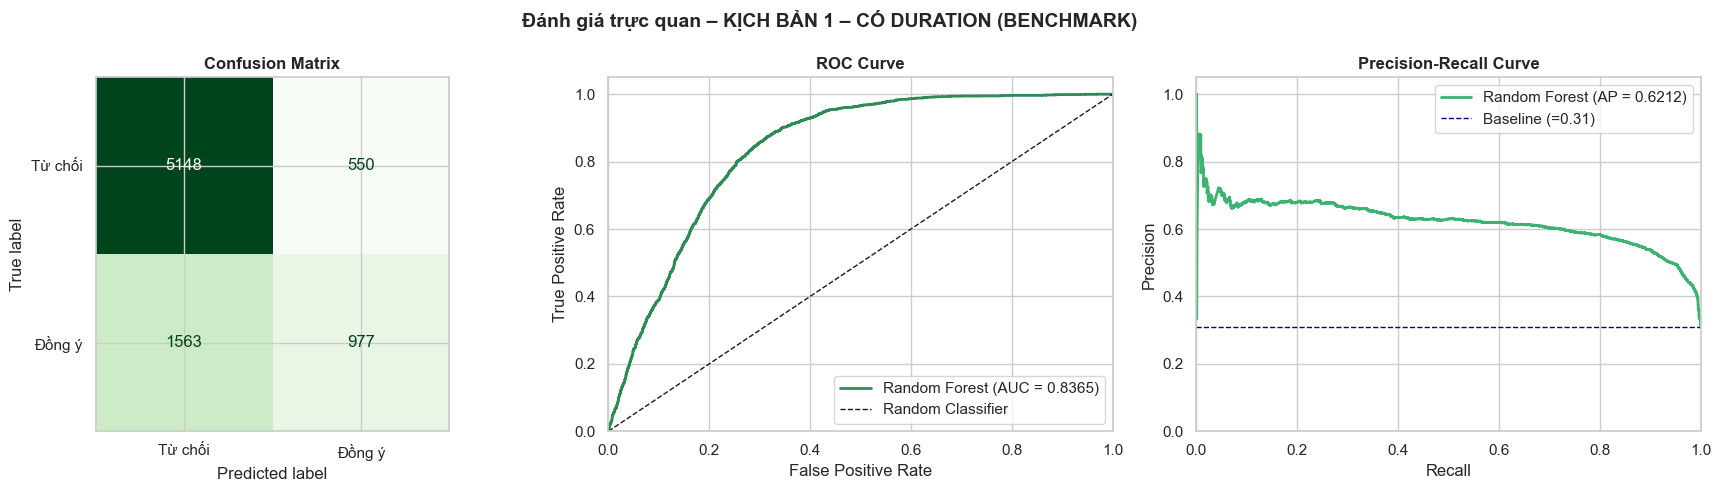



BÁO CÁO MÔ HÌNH: KỊCH BẢN 2 – KHÔNG DURATION (THỰC TẾ)

 1. CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Từ chối (0)       0.74      0.86      0.80      5698
  Đồng ý (1)       0.51      0.33      0.40      2540

    accuracy                           0.70      8238
   macro avg       0.63      0.59      0.60      8238
weighted avg       0.67      0.70      0.67      8238

 2. CHỈ SỐ TỔNG HỢP:
   ROC-AUC           : 0.7212
   PR-AUC            : 0.4803
   F1-Score (class 1): 0.4011
   Balanced Accuracy : 0.5948


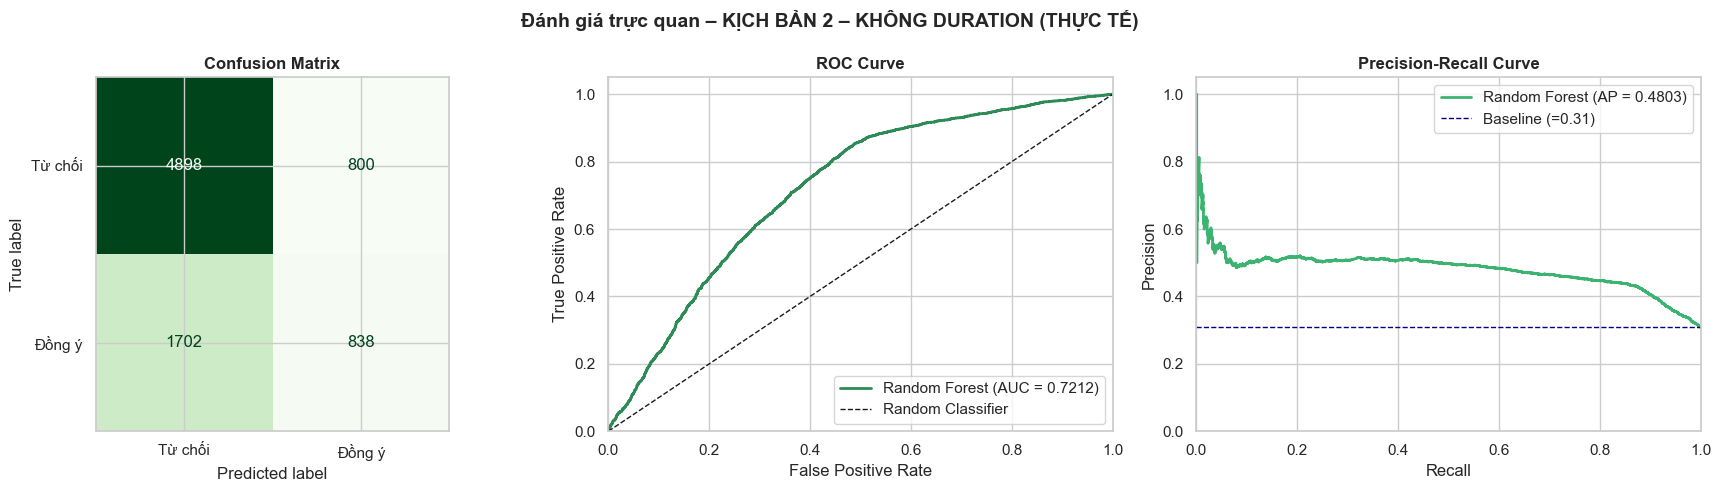

In [ ]:
def evaluate_model_generic(model, X_te, y_te, scenario_name, model_name='Model'):
    """
    Hàm đánh giá tổng quát cho bất kỳ mô hình sklearn nào.
    - Classification Report
    - ROC-AUC, PR-AUC, F1, Balanced Accuracy
    - Confusion Matrix, ROC Curve, PR Curve
    """
    print(f"{'='*60}")
    print(f"BÁO CÁO MÔ HÌNH: {scenario_name}")
    print(f"{'='*60}")

    y_pred       = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1]

    roc_auc = roc_auc_score(y_te, y_pred_proba)
    pr_auc  = average_precision_score(y_te, y_pred_proba)
    f1      = f1_score(y_te, y_pred, pos_label=1)
    bal_acc = balanced_accuracy_score(y_te, y_pred)

    print("\n 1. CLASSIFICATION REPORT:")
    print(classification_report(y_te, y_pred,
                                target_names=['Từ chối (0)', 'Đồng ý (1)']))

    print(" 2. CHỈ SỐ TỔNG HỢP:")
    print(f"   ROC-AUC           : {roc_auc:.4f}")
    print(f"   PR-AUC            : {pr_auc:.4f}")
    print(f"   F1-Score (class 1): {f1:.4f}")
    print(f"   Balanced Accuracy : {bal_acc:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Đánh giá trực quan – {scenario_name}", fontsize=14, fontweight='bold')

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Từ chối', 'Đồng ý'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
    axes[0].set_title('Confusion Matrix', fontweight='bold')

    fpr, tpr, _ = roc_curve(y_te, y_pred_proba)
    axes[1].plot(fpr, tpr, color='seagreen', lw=2,
                 label=f'{model_name} (AUC = {roc_auc:.4f})')
    axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve', fontweight='bold')
    axes[1].legend(loc='lower right')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])

    prec, rec, _ = precision_recall_curve(y_te, y_pred_proba)
    baseline = y_te.mean()
    axes[2].plot(rec, prec, color='mediumseagreen', lw=2,
                 label=f'{model_name} (AP = {pr_auc:.4f})')
    axes[2].axhline(y=baseline, color='navy', linestyle='--', lw=1,
                    label=f'Baseline (={baseline:.2f})')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall Curve', fontweight='bold')
    axes[2].legend(loc='upper right')
    axes[2].set_xlim([0.0, 1.0])
    axes[2].set_ylim([0.0, 1.05])

    plt.tight_layout()
    plt.show()

    return {
        'roc_auc'     : roc_auc,
        'pr_auc'      : pr_auc,
        'f1'          : f1,
        'bal_acc'     : bal_acc,
        'y_pred_proba': y_pred_proba,
        'y_pred'      : y_pred,
    }


print("\n")
rf_results1 = evaluate_model_generic(best_rf1, X_te1, y_test,
                                     "KỊCH BẢN 1 – CÓ DURATION (BENCHMARK)",
                                     model_name='Random Forest')
print("\n")
rf_results2 = evaluate_model_generic(best_rf2, X_te2, y_test,
                                     "KỊCH BẢN 2 – KHÔNG DURATION (THỰC TẾ)",
                                     model_name='Random Forest')

## Giải thích mô hình Random Forest

### 1. Feature Importance (Mean Decrease in Impurity)

=== Kịch bản 1 - Có duration ===


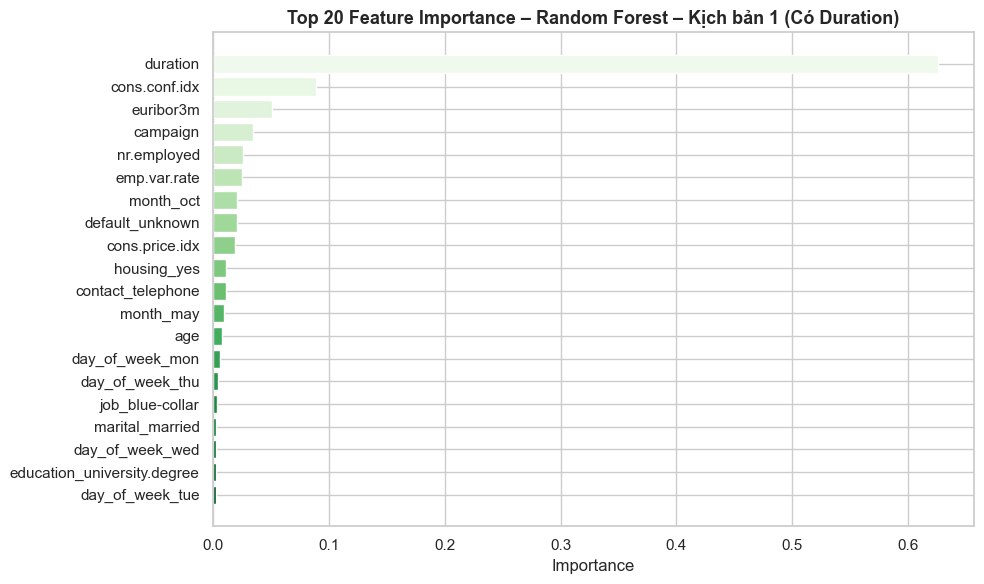


 Top 20 features:
   duration                           : 0.6257
   cons.conf.idx                      : 0.0893
   euribor3m                          : 0.0511
   campaign                           : 0.0348
   nr.employed                        : 0.0260
   emp.var.rate                       : 0.0249
   month_oct                          : 0.0208
   default_unknown                    : 0.0203
   cons.price.idx                     : 0.0190
   housing_yes                        : 0.0114
   contact_telephone                  : 0.0108
   month_may                          : 0.0094
   age                                : 0.0081
   day_of_week_mon                    : 0.0060
   day_of_week_thu                    : 0.0046
   job_blue-collar                    : 0.0036
   marital_married                    : 0.0027
   day_of_week_wed                    : 0.0026
   education_university.degree        : 0.0026
   day_of_week_tue                    : 0.0023

=== Kịch bản 2 - Không duration ===


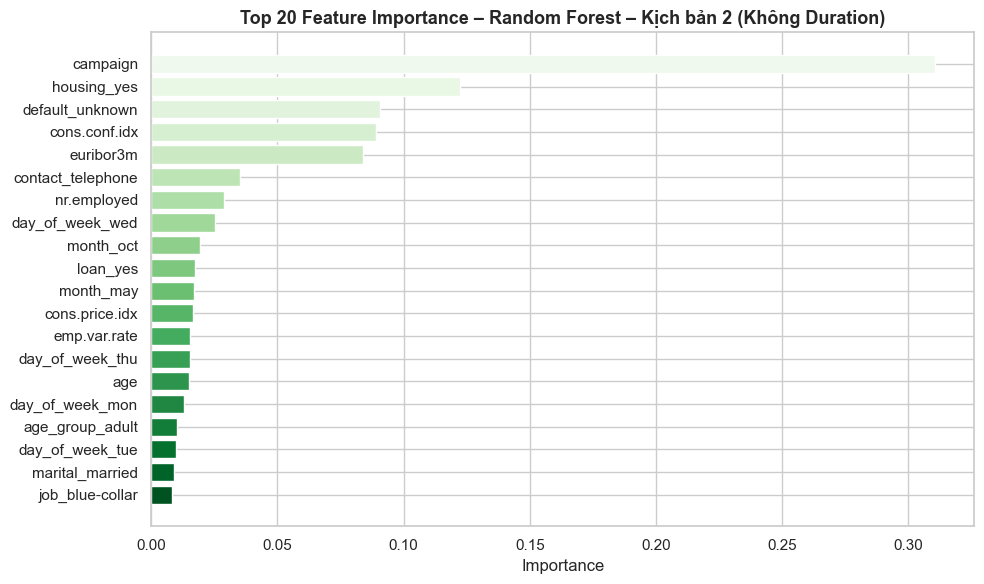


 Top 20 features:
   campaign                           : 0.3106
   housing_yes                        : 0.1224
   default_unknown                    : 0.0906
   cons.conf.idx                      : 0.0892
   euribor3m                          : 0.0841
   contact_telephone                  : 0.0353
   nr.employed                        : 0.0288
   day_of_week_wed                    : 0.0251
   month_oct                          : 0.0191
   loan_yes                           : 0.0171
   month_may                          : 0.0171
   cons.price.idx                     : 0.0164
   emp.var.rate                       : 0.0153
   day_of_week_thu                    : 0.0152
   age                                : 0.0151
   day_of_week_mon                    : 0.0131
   age_group_adult                    : 0.0101
   day_of_week_tue                    : 0.0097
   marital_married                    : 0.0091
   job_blue-collar                    : 0.0083


In [ ]:
def plot_feature_importance_generic(model, feature_names, top_n=20, title='', color_palette='Greens_r'):

    importances = model.feature_importances_
    fi_df = pd.DataFrame({
        'feature'   : list(feature_names),
        'importance': importances,
    }).sort_values('importance', ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
                    color=sns.color_palette(color_palette, top_n))
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'Top {top_n} Feature Importance – {title}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n Top {top_n} features:")
    for _, row in fi_df.iterrows():
        print(f"   {row['feature']:<35s}: {row['importance']:.4f}")
    return fi_df


print("=== Kịch bản 1 - Có duration ===")
rf_fi1 = plot_feature_importance_generic(best_rf1, X_tr1.columns, top_n=20,
                                         title='Random Forest – Kịch bản 1 (Có Duration)',
                                         color_palette='Greens_r')

print("\n=== Kịch bản 2 - Không duration ===")
rf_fi2 = plot_feature_importance_generic(best_rf2, X_tr2.columns, top_n=20,
                                         title='Random Forest – Kịch bản 2 (Không Duration)',
                                         color_palette='Greens_r')

### 2. SHAP Values – Giải thích mô hình theo từng mẫu

======= Random Forest – KỊCH BẢN 2 – KHÔNG DURATION (thực tế) =======

SHAP Summary Plot (Beeswarm):


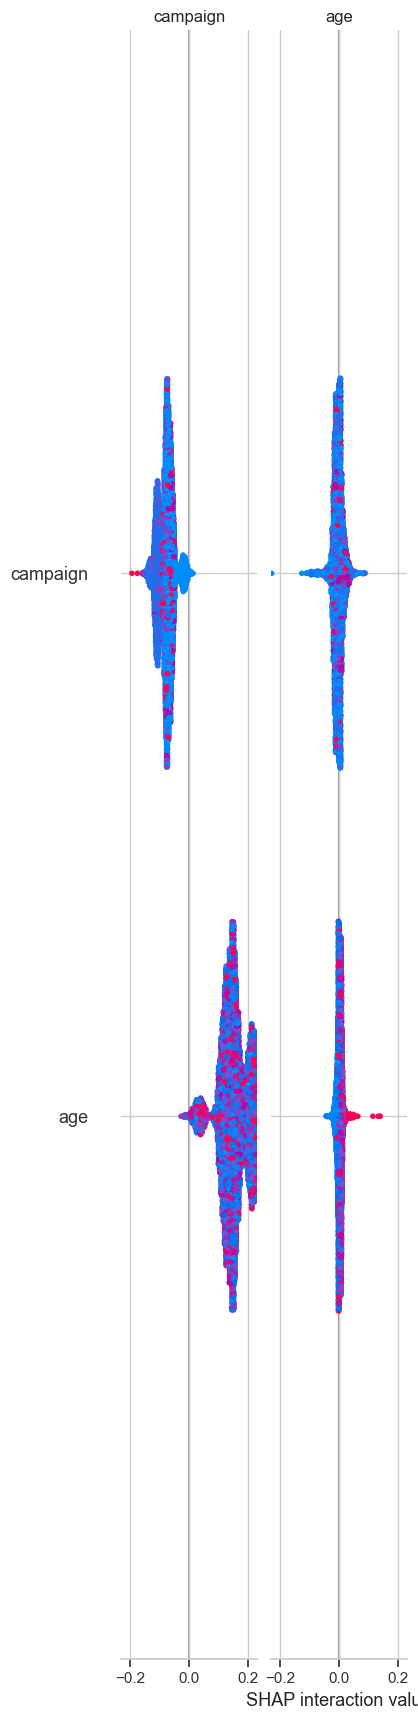


SHAP Bar Plot (Mean |SHAP|):


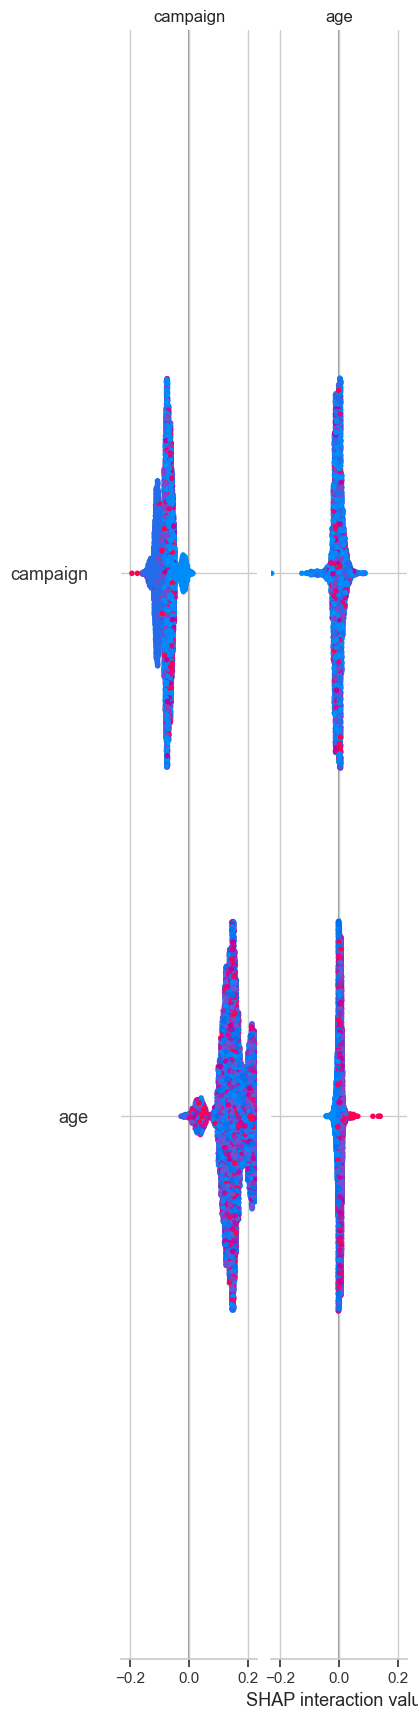

In [ ]:
print("======= Random Forest – KỊCH BẢN 2 – KHÔNG DURATION (thực tế) =======")
rf_explainer2, rf_shap_vals2 = shap_analysis(best_rf2, X_te2)

SHAP Waterfall Plot – Random Forest – Giải thích mẫu index 0 (lớp dương):


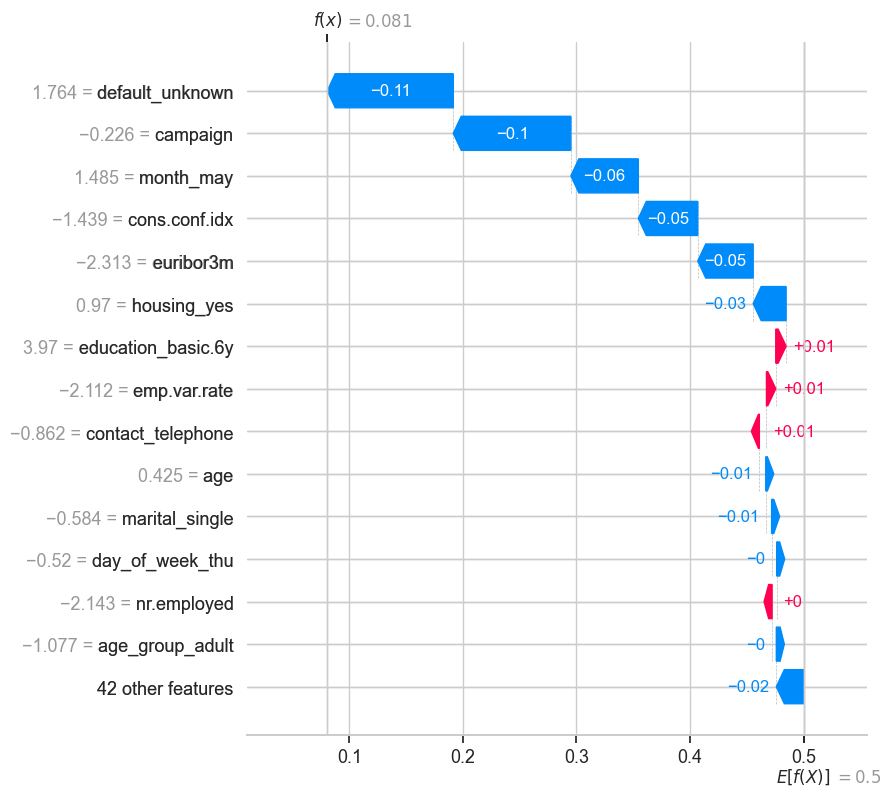

In [ ]:
# SHAP Waterfall cho mẫu index 0 – Random Forest, chọn lớp dương (output index = 1)
print("SHAP Waterfall Plot – Random Forest – Giải thích mẫu index 0 (lớp dương):")
output_idx = 1
rf_shap_explanation = shap.Explanation(
    values=rf_shap_vals2[0, :, output_idx],
    base_values=rf_explainer2.expected_value[output_idx],
    data=X_te2.iloc[0],
    feature_names=X_te2.columns.tolist()
)
shap.waterfall_plot(rf_shap_explanation, max_display=15)

## Phân tích Ngưỡng Quyết định – Random Forest

> Điều chỉnh ngưỡng để tối ưu F1-Score cho Kịch bản 2.

=== Random Forest – Kịch bản 2 – Phân tích ngưỡng ===


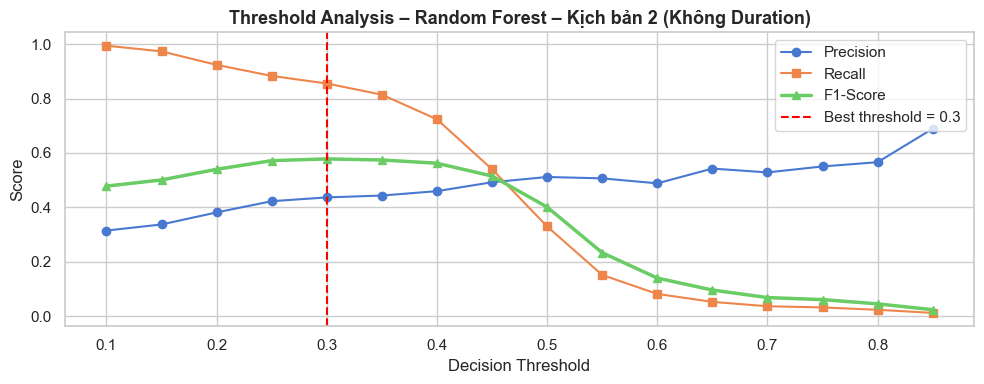

 Ngưỡng tốt nhất (theo F1): 0.3
 Precision=0.4366 | Recall=0.8551 | F1=0.5780


In [ ]:
print("=== Random Forest – Kịch bản 2 – Phân tích ngưỡng ===")
rf_best_t2, rf_df_thresh2 = threshold_analysis(
    y_test, rf_results2['y_pred_proba'], 'Random Forest – Kịch bản 2 (Không Duration)'
)

In [ ]:
# Đánh giá lại Random Forest Kịch bản 2 với ngưỡng tốt nhất
rf_pred_best_t = (rf_results2['y_pred_proba'] >= rf_best_t2).astype(int)

print(f"\n Classification Report – Random Forest với ngưỡng tối ưu (threshold={rf_best_t2}):")
print(classification_report(y_test, rf_pred_best_t,
                            target_names=['Từ chối (0)', 'Đồng ý (1)']))


 Classification Report – Random Forest với ngưỡng tối ưu (threshold=0.3):
              precision    recall  f1-score   support

 Từ chối (0)       0.89      0.51      0.65      5698
  Đồng ý (1)       0.44      0.86      0.58      2540

    accuracy                           0.62      8238
   macro avg       0.66      0.68      0.61      8238
weighted avg       0.75      0.62      0.63      8238



---
## PHẦN III – MÔ HÌNH LIGHTGBM
---

## Tối ưu Siêu tham số LightGBM bằng RandomizedSearchCV
> Tối ưu theo chỉ số **ROC-AUC**.

In [ ]:
# Không gian tham số cho LightGBM
lgbm_param_dist = {
    'n_estimators'     : randint(100, 600),
    'max_depth'        : randint(3, 12),
    'learning_rate'    : uniform(0.01, 0.3),
    'num_leaves'       : randint(15, 150),
    'min_child_samples': randint(10, 100),
    'subsample'        : uniform(0.6, 0.4),          # [0.6, 1.0]
    'colsample_bytree' : uniform(0.6, 0.4),          # [0.6, 1.0]
    'reg_alpha'        : uniform(0, 1),               # L1
    'reg_lambda'       : uniform(0, 2),               # L2
    'scale_pos_weight' : uniform(1, 5),               # xử lý mất cân bằng
}

def tune_lightgbm(X_tr, y_tr, n_iter=50, label=''):
    print(f"Siêu tham số tốt nhất cho {label}:")
    base_lgbm = lgb.LGBMClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    search = RandomizedSearchCV(
        estimator=base_lgbm,
        param_distributions=lgbm_param_dist,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=TimeSeriesSplit(n_splits=5),
        verbose=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    search.fit(X_tr, y_tr)
    print(f"   Best ROC-AUC (CV): {search.best_score_:.4f}")
    print(f"   Best params: {search.best_params_}")
    return search.best_estimator_, search

# Kịch bản 1 – Có duration
best_lgbm1, lgbm_search1 = tune_lightgbm(X_tr1, y_tr1, n_iter=50, label='Kịch bản 1 - Có duration')

# Kịch bản 2 – Không duration
best_lgbm2, lgbm_search2 = tune_lightgbm(X_tr2, y_tr2, n_iter=50, label='Kịch bản 2 - Không duration')

Siêu tham số tốt nhất cho Kịch bản 1 - Có duration:
Fitting 5 folds for each of 50 candidates, totalling 250 fits
   Best ROC-AUC (CV): nan
   Best params: {'colsample_bytree': np.float64(0.749816047538945), 'learning_rate': np.float64(0.2952142919229748), 'max_depth': 10, 'min_child_samples': 70, 'n_estimators': 120, 'num_leaves': 117, 'reg_alpha': np.float64(0.44583275285359114), 'reg_lambda': np.float64(0.19994983163600577), 'scale_pos_weight': np.float64(3.2962444598293357), 'subsample': np.float64(0.7334834444556088)}
Siêu tham số tốt nhất cho Kịch bản 2 - Không duration:
Fitting 5 folds for each of 50 candidates, totalling 250 fits
   Best ROC-AUC (CV): nan
   Best params: {'colsample_bytree': np.float64(0.749816047538945), 'learning_rate': np.float64(0.2952142919229748), 'max_depth': 10, 'min_child_samples': 70, 'n_estimators': 120, 'num_leaves': 117, 'reg_alpha': np.float64(0.44583275285359114), 'reg_lambda': np.float64(0.19994983163600577), 'scale_pos_weight': np.float64(3.296

## Đánh giá mô hình LightGBM



BÁO CÁO MÔ HÌNH: KỊCH BẢN 1 – CÓ DURATION (BENCHMARK)

 1. CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Từ chối (0)       0.73      0.96      0.83      5698
  Đồng ý (1)       0.70      0.21      0.33      2540

    accuracy                           0.73      8238
   macro avg       0.71      0.59      0.58      8238
weighted avg       0.72      0.73      0.67      8238

 2. CHỈ SỐ TỔNG HỢP:
   ROC-AUC           : 0.8099
   PR-AUC            : 0.6091
   F1-Score (class 1): 0.3254
   Balanced Accuracy : 0.5856


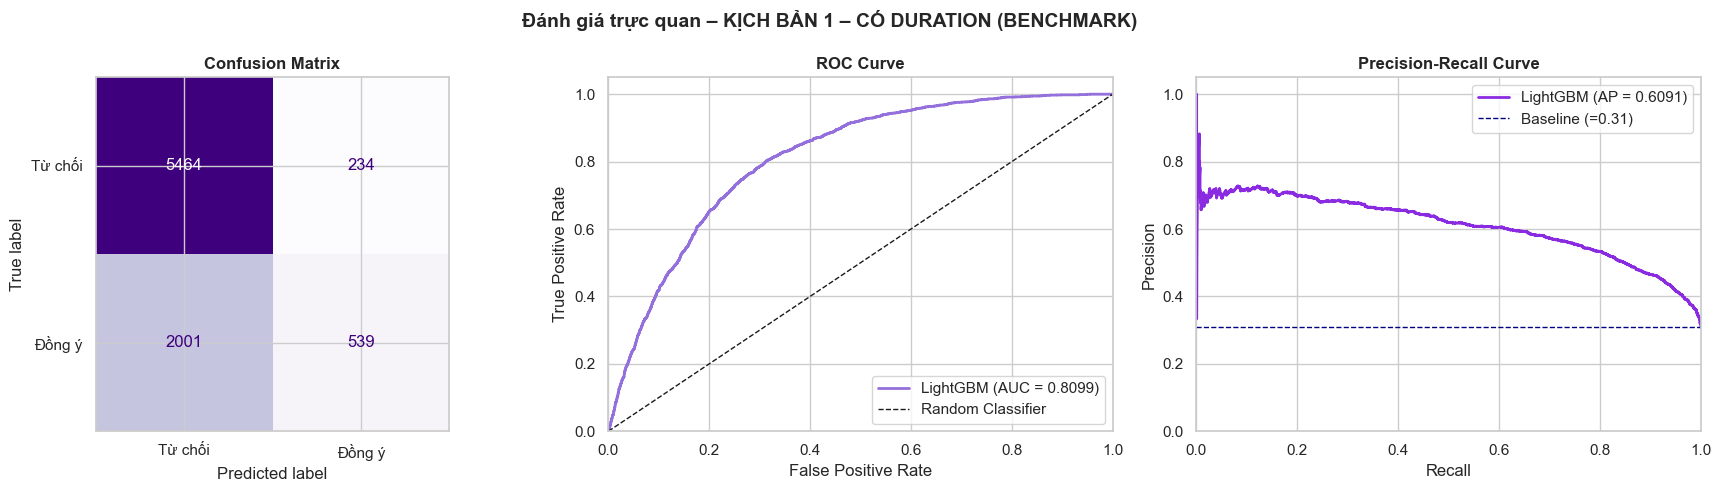



BÁO CÁO MÔ HÌNH: KỊCH BẢN 2 – KHÔNG DURATION (THỰC TẾ)

 1. CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Từ chối (0)       0.70      0.97      0.82      5698
  Đồng ý (1)       0.56      0.08      0.15      2540

    accuracy                           0.70      8238
   macro avg       0.63      0.53      0.48      8238
weighted avg       0.66      0.70      0.61      8238

 2. CHỈ SỐ TỔNG HỢP:
   ROC-AUC           : 0.5953
   PR-AUC            : 0.4018
   F1-Score (class 1): 0.1470
   Balanced Accuracy : 0.5273


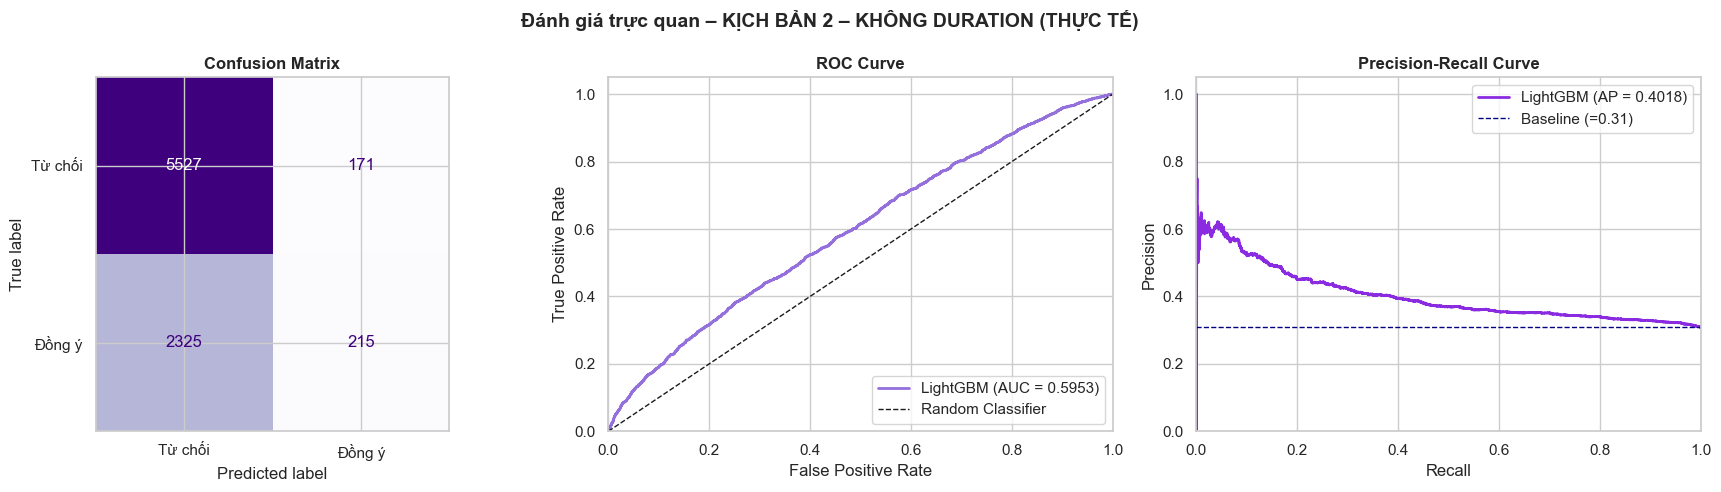

In [ ]:
def evaluate_lightgbm(model, X_te, y_te, scenario_name):
    """
    Đánh giá LightGBM – dùng màu tím để phân biệt với XGBoost (xanh dương) và RF (xanh lá).
    """
    print(f"{'='*60}")
    print(f"BÁO CÁO MÔ HÌNH: {scenario_name}")
    print(f"{'='*60}")

    y_pred       = model.predict(X_te)
    y_pred_proba = model.predict_proba(X_te)[:, 1]

    roc_auc = roc_auc_score(y_te, y_pred_proba)
    pr_auc  = average_precision_score(y_te, y_pred_proba)
    f1      = f1_score(y_te, y_pred, pos_label=1)
    bal_acc = balanced_accuracy_score(y_te, y_pred)

    print("\n 1. CLASSIFICATION REPORT:")
    print(classification_report(y_te, y_pred,
                                target_names=['Từ chối (0)', 'Đồng ý (1)']))

    print(" 2. CHỈ SỐ TỔNG HỢP:")
    print(f"   ROC-AUC           : {roc_auc:.4f}")
    print(f"   PR-AUC            : {pr_auc:.4f}")
    print(f"   F1-Score (class 1): {f1:.4f}")
    print(f"   Balanced Accuracy : {bal_acc:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Đánh giá trực quan – {scenario_name}", fontsize=14, fontweight='bold')

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Từ chối', 'Đồng ý'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Purples')
    axes[0].set_title('Confusion Matrix', fontweight='bold')

    fpr, tpr, _ = roc_curve(y_te, y_pred_proba)
    axes[1].plot(fpr, tpr, color='mediumpurple', lw=2,
                 label=f'LightGBM (AUC = {roc_auc:.4f})')
    axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve', fontweight='bold')
    axes[1].legend(loc='lower right')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])

    prec, rec, _ = precision_recall_curve(y_te, y_pred_proba)
    baseline = y_te.mean()
    axes[2].plot(rec, prec, color='blueviolet', lw=2,
                 label=f'LightGBM (AP = {pr_auc:.4f})')
    axes[2].axhline(y=baseline, color='navy', linestyle='--', lw=1,
                    label=f'Baseline (={baseline:.2f})')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall Curve', fontweight='bold')
    axes[2].legend(loc='upper right')
    axes[2].set_xlim([0.0, 1.0])
    axes[2].set_ylim([0.0, 1.05])

    plt.tight_layout()
    plt.show()

    return {
        'roc_auc'     : roc_auc,
        'pr_auc'      : pr_auc,
        'f1'          : f1,
        'bal_acc'     : bal_acc,
        'y_pred_proba': y_pred_proba,
        'y_pred'      : y_pred,
    }


print("\n")
lgbm_results1 = evaluate_lightgbm(best_lgbm1, X_te1, y_test,
                                   "KỊCH BẢN 1 – CÓ DURATION (BENCHMARK)")
print("\n")
lgbm_results2 = evaluate_lightgbm(best_lgbm2, X_te2, y_test,
                                   "KỊCH BẢN 2 – KHÔNG DURATION (THỰC TẾ)")

## 17. Giải thích mô hình LightGBM

### 17.1 Feature Importance (Split Count)

=== Kịch bản 1 - Có duration ===


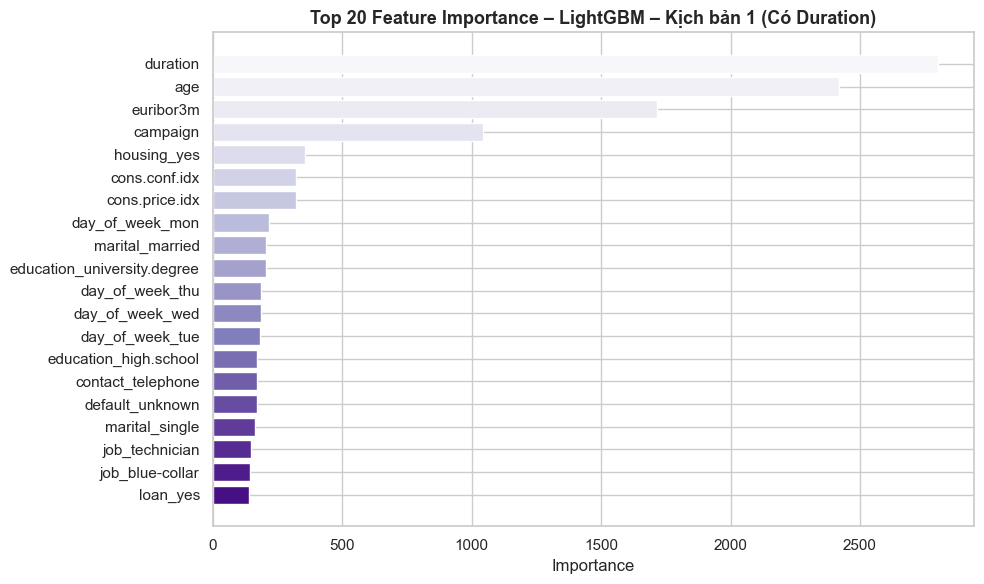


 Top 20 features:
   duration                           : 2801.0000
   age                                : 2420.0000
   euribor3m                          : 1717.0000
   campaign                           : 1043.0000
   housing_yes                        : 354.0000
   cons.conf.idx                      : 320.0000
   cons.price.idx                     : 320.0000
   day_of_week_mon                    : 217.0000
   marital_married                    : 206.0000
   education_university.degree        : 203.0000
   day_of_week_thu                    : 185.0000
   day_of_week_wed                    : 184.0000
   day_of_week_tue                    : 180.0000
   education_high.school              : 171.0000
   contact_telephone                  : 170.0000
   default_unknown                    : 169.0000
   marital_single                     : 163.0000
   job_technician                     : 145.0000
   job_blue-collar                    : 142.0000
   loan_yes                           : 139.00

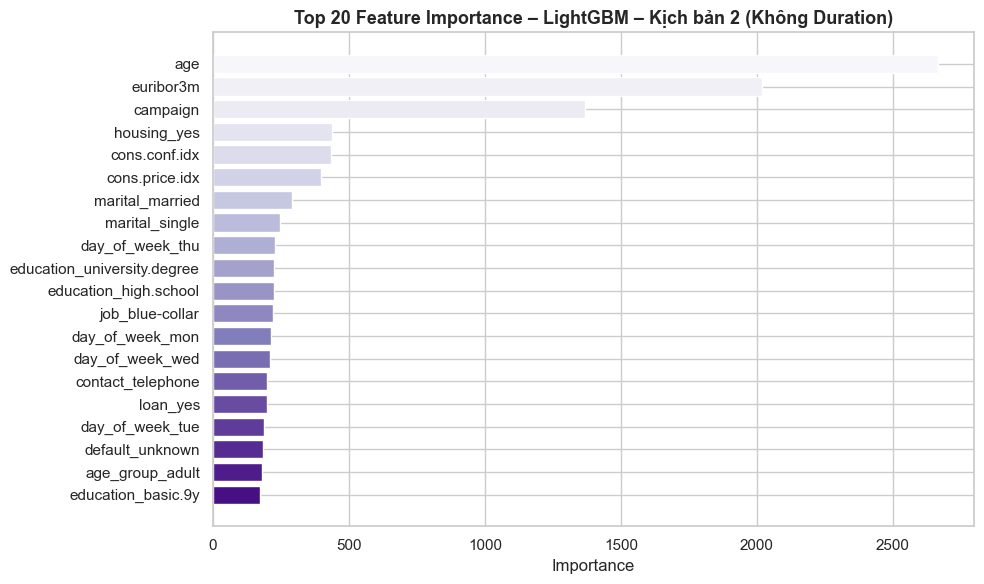


 Top 20 features:
   age                                : 2665.0000
   euribor3m                          : 2019.0000
   campaign                           : 1369.0000
   housing_yes                        : 436.0000
   cons.conf.idx                      : 434.0000
   cons.price.idx                     : 398.0000
   marital_married                    : 290.0000
   marital_single                     : 245.0000
   day_of_week_thu                    : 227.0000
   education_university.degree        : 224.0000
   education_high.school              : 223.0000
   job_blue-collar                    : 222.0000
   day_of_week_mon                    : 212.0000
   day_of_week_wed                    : 208.0000
   contact_telephone                  : 200.0000
   loan_yes                           : 197.0000
   day_of_week_tue                    : 187.0000
   default_unknown                    : 182.0000
   age_group_adult                    : 181.0000
   education_basic.9y                 : 172.000

In [ ]:
print("=== Kịch bản 1 - Có duration ===")
lgbm_fi1 = plot_feature_importance_generic(best_lgbm1, X_tr1.columns, top_n=20,
                                           title='LightGBM – Kịch bản 1 (Có Duration)',
                                           color_palette='Purples_r')

print("\n=== Kịch bản 2 - Không duration ===")
lgbm_fi2 = plot_feature_importance_generic(best_lgbm2, X_tr2.columns, top_n=20,
                                           title='LightGBM – Kịch bản 2 (Không Duration)',
                                           color_palette='Purples_r')

### 17.2 SHAP Values – Giải thích mô hình theo từng mẫu

======= LightGBM – KỊCH BẢN 2 – KHÔNG DURATION (thực tế) =======

SHAP Summary Plot (Beeswarm):


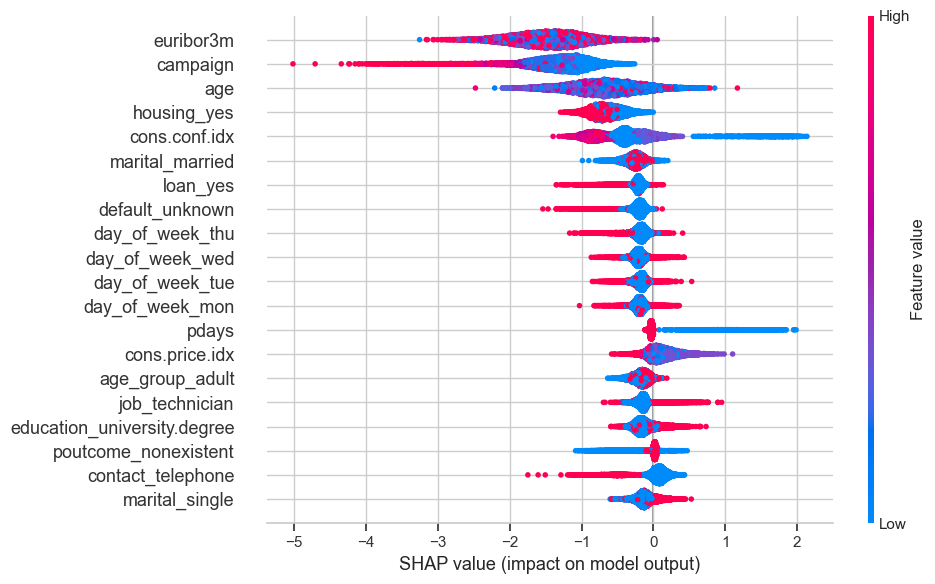


SHAP Bar Plot (Mean |SHAP|):


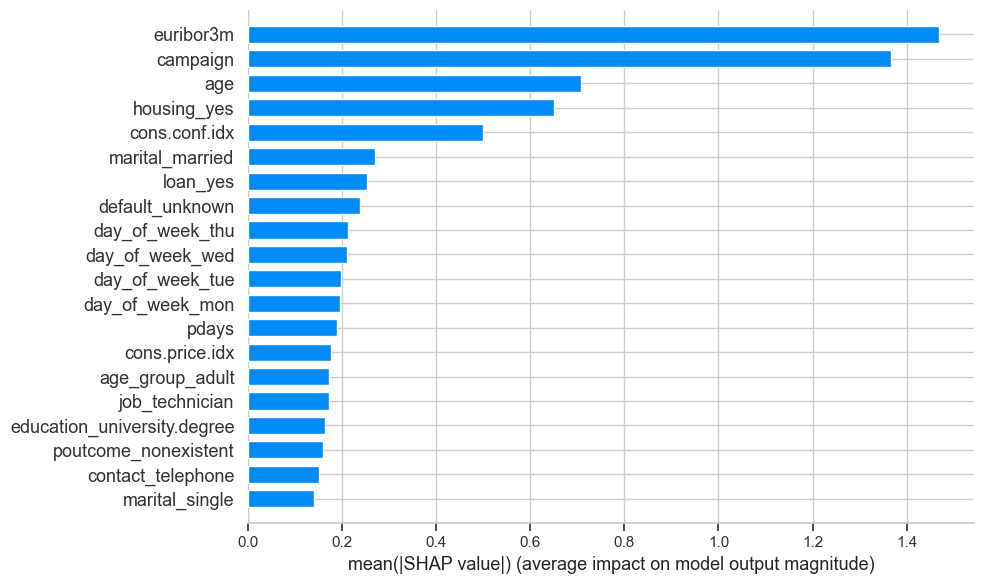

In [ ]:
print("======= LightGBM – KỊCH BẢN 2 – KHÔNG DURATION (thực tế) =======")
lgbm_explainer2, lgbm_shap_vals2 = shap_analysis(best_lgbm2, X_te2)

SHAP Waterfall Plot – LightGBM – Giải thích mẫu index 0:


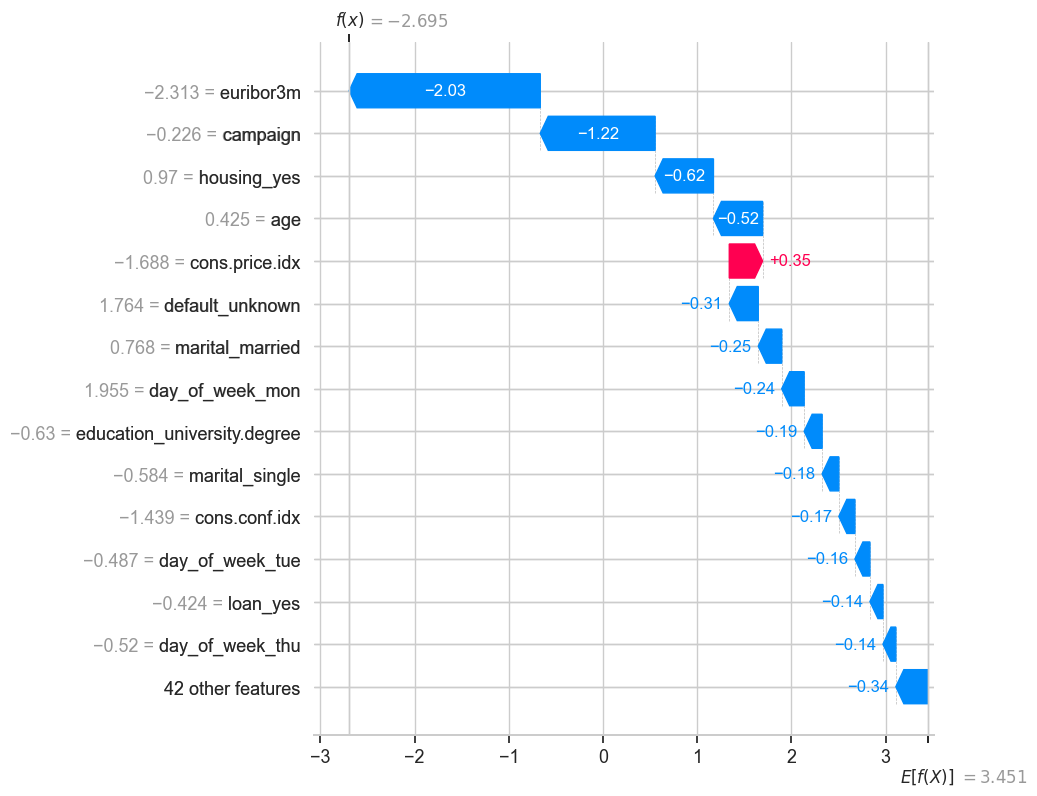

In [ ]:
# SHAP Waterfall cho mẫu index 0 – LightGBM
print("SHAP Waterfall Plot – LightGBM – Giải thích mẫu index 0:")
lgbm_shap_explanation = shap.Explanation(
    values=lgbm_shap_vals2[0],
    base_values=lgbm_explainer2.expected_value,
    data=X_te2.iloc[0],
    feature_names=X_te2.columns.tolist()
)
shap.waterfall_plot(lgbm_shap_explanation, max_display=15)

## 18. Phân tích Ngưỡng Quyết định – LightGBM

> Điều chỉnh ngưỡng để tối ưu F1-Score cho Kịch bản 2.

=== LightGBM – Kịch bản 2 – Phân tích ngưỡng ===


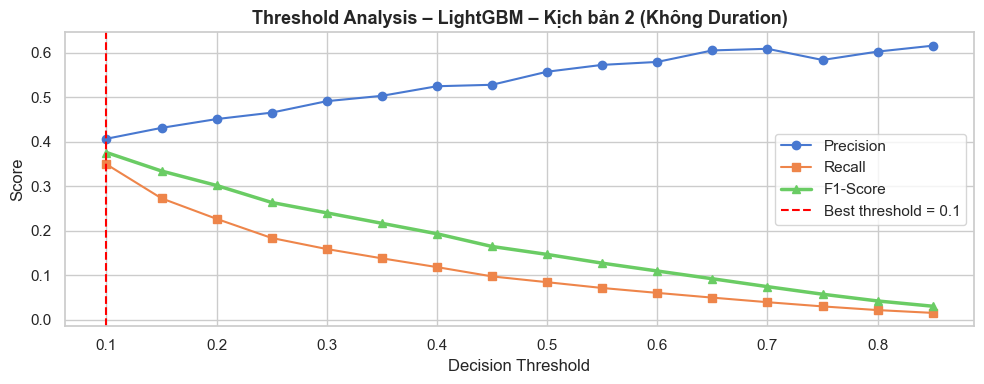

 Ngưỡng tốt nhất (theo F1): 0.1
 Precision=0.4065 | Recall=0.3492 | F1=0.3757


In [ ]:
print("=== LightGBM – Kịch bản 2 – Phân tích ngưỡng ===")
lgbm_best_t2, lgbm_df_thresh2 = threshold_analysis(
    y_test, lgbm_results2['y_pred_proba'], 'LightGBM – Kịch bản 2 (Không Duration)'
)

In [ ]:
# Đánh giá lại LightGBM Kịch bản 2 với ngưỡng tốt nhất
lgbm_pred_best_t = (lgbm_results2['y_pred_proba'] >= lgbm_best_t2).astype(int)

print(f"\n Classification Report – LightGBM với ngưỡng tối ưu (threshold={lgbm_best_t2}):")
print(classification_report(y_test, lgbm_pred_best_t,
                            target_names=['Từ chối (0)', 'Đồng ý (1)']))


 Classification Report – LightGBM với ngưỡng tối ưu (threshold=0.1):
              precision    recall  f1-score   support

 Từ chối (0)       0.73      0.77      0.75      5698
  Đồng ý (1)       0.41      0.35      0.38      2540

    accuracy                           0.64      8238
   macro avg       0.57      0.56      0.56      8238
weighted avg       0.63      0.64      0.63      8238



## So sánh tổng hợp: Logistic Regression vs XGBoost vs Random Forest vs LightGBM

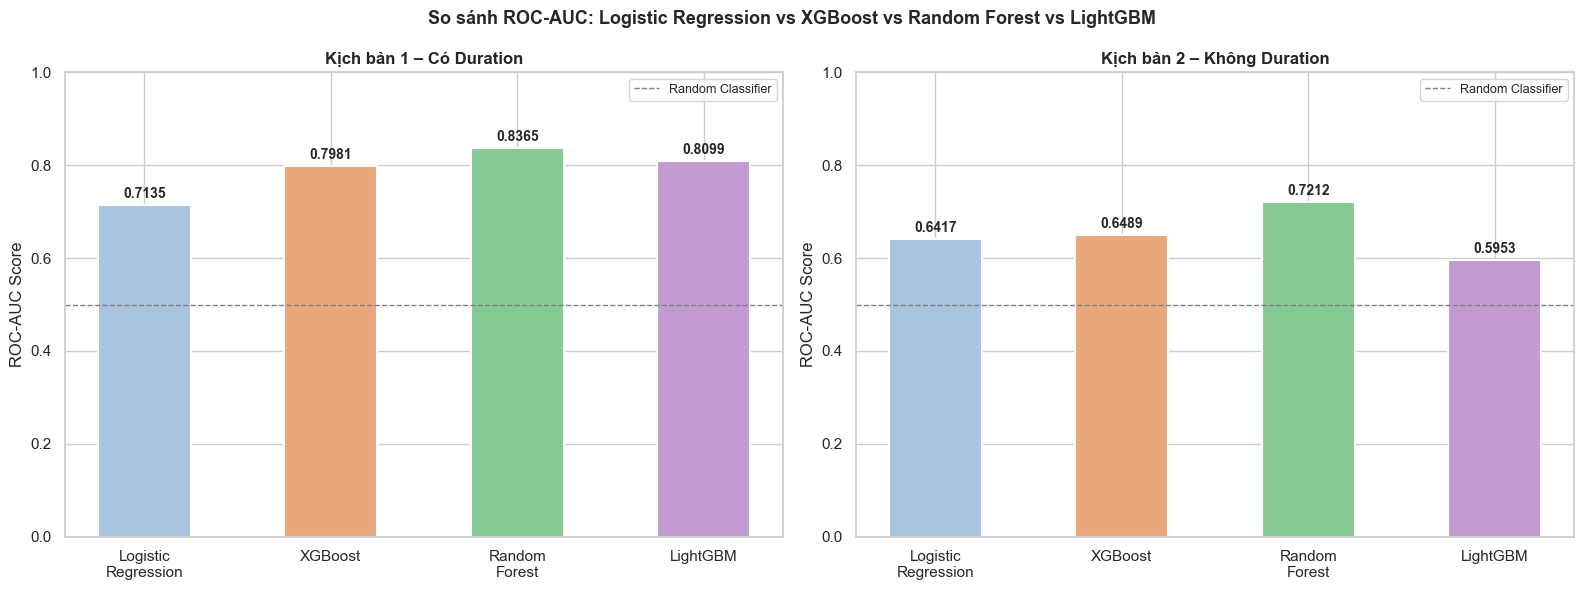


 BẢNG TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH:
                     ROC-AUC  PR-AUC  F1-Score (class 1)  Balanced Accuracy
Mô hình                                                                    
LR (KB1)              0.7135     NaN                 NaN                NaN
LR (KB2)              0.6417     NaN                 NaN                NaN
XGBoost (KB1)         0.7981  0.5828              0.2668             0.5654
XGBoost (KB2)         0.6489  0.4313              0.3351             0.5675
Random Forest (KB1)   0.8365  0.6212              0.4805             0.6441
Random Forest (KB2)   0.7212  0.4803              0.4011             0.5948
LightGBM (KB1)        0.8099  0.6091              0.3254             0.5856
LightGBM (KB2)        0.5953  0.4018              0.1470             0.5273


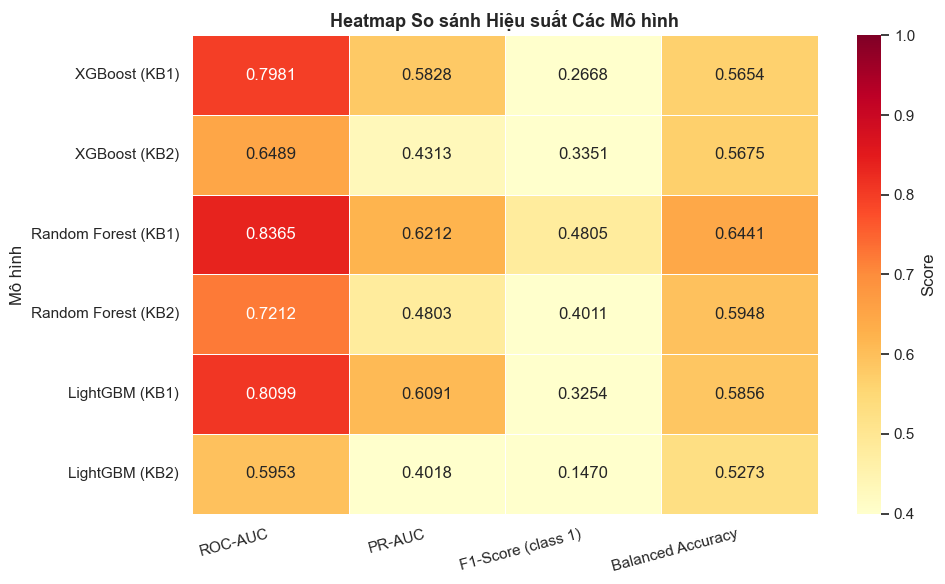

In [ ]:
# So sánh ROC-AUC theo kịch bản
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('So sánh ROC-AUC: Logistic Regression vs XGBoost vs Random Forest vs LightGBM',
             fontsize=13, fontweight='bold')

for ax, (kb_label, lr_val, xgb_val, rf_val, lgbm_val) in zip(
    axes,
    [
        ('Kịch bản 1 – Có Duration',
         0.7135, results1['roc_auc'], rf_results1['roc_auc'], lgbm_results1['roc_auc']),
        ('Kịch bản 2 – Không Duration',
         0.6417, results2['roc_auc'], rf_results2['roc_auc'], lgbm_results2['roc_auc']),
    ]
):
    models_labels = ['Logistic\nRegression', 'XGBoost', 'Random\nForest', 'LightGBM']
    roc_vals      = [lr_val, xgb_val, rf_val, lgbm_val]
    bar_colors    = ['#A8C4E0', '#E8A87C', '#85C995', '#C39BD3']

    bars = ax.bar(models_labels, roc_vals, color=bar_colors,
                  edgecolor='white', linewidth=1.5, width=0.5)
    ax.bar_label(bars, fmt='%.4f', fontsize=10, fontweight='bold', padding=3)
    ax.set_ylim(0, 1.0)
    ax.axhline(y=0.5, color='gray', linestyle='--', lw=1, label='Random Classifier')
    ax.set_ylabel('ROC-AUC Score', fontsize=12)
    ax.set_title(kb_label, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Bảng tổng hợp tất cả chỉ số
summary_data = {
    'Mô hình'           : ['LR (KB1)', 'LR (KB2)',
                            'XGBoost (KB1)', 'XGBoost (KB2)',
                            'Random Forest (KB1)', 'Random Forest (KB2)',
                            'LightGBM (KB1)', 'LightGBM (KB2)'],
    'ROC-AUC'           : [0.7135, 0.6417,
                            results1['roc_auc'],   results2['roc_auc'],
                            rf_results1['roc_auc'], rf_results2['roc_auc'],
                            lgbm_results1['roc_auc'], lgbm_results2['roc_auc']],
    'PR-AUC'            : [None, None,
                            results1['pr_auc'],   results2['pr_auc'],
                            rf_results1['pr_auc'], rf_results2['pr_auc'],
                            lgbm_results1['pr_auc'], lgbm_results2['pr_auc']],
    'F1-Score (class 1)': [None, None,
                            results1['f1'],   results2['f1'],
                            rf_results1['f1'], rf_results2['f1'],
                            lgbm_results1['f1'], lgbm_results2['f1']],
    'Balanced Accuracy' : [None, None,
                            results1['bal_acc'],   results2['bal_acc'],
                            rf_results1['bal_acc'], rf_results2['bal_acc'],
                            lgbm_results1['bal_acc'], lgbm_results2['bal_acc']],
}

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.set_index('Mô hình')

print("\n BẢNG TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH:")
print("=" * 75)
print(df_summary.to_string(float_format=lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A'))
print("=" * 75)

# Heatmap tổng hợp
heatmap_data = df_summary.dropna().astype(float)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Score'}, vmin=0.4, vmax=1.0)
plt.title('Heatmap So sánh Hiệu suất Các Mô hình', fontsize=13, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()